# Batsman Stats Workflow — LangGraph (Parallelization)

A simple workflow to understand the **Parallelization** pattern in
LangGraph: multiple independent calculations run in parallel (at the
same time), each reading from the same state and writing back its
own piece of the result.

**What it does:**

- Takes match stats as INPUT: `runs`, `balls`, `no_of_4s`, `no_of_6s`.
- Runs several calculations in PARALLEL:
  - Strike Rate
  - Balls per Boundary
  - Boundary Percentage
- Merges all the results together into a final SUMMARY.

**How it's built:**

- The whole workflow is represented as a **GRAPH** — multiple nodes
  branching out from the same point and joining back together, the
  LangGraph way of doing parallelization.
- It has a **STATE** — a shared dictionary that holds all the raw
  inputs and all the calculated outputs. Each parallel node reads
  what it needs from the state and writes its own result back in.


In [18]:
from typing import TypedDict


class BatsmanState(TypedDict):
    runs: int
    balls: int
    no_of_4s: int
    no_of_6s: int
    sr: float
    ball_per_boundry: float
    boundry_percentage: float
    summary: str

In [19]:
def calculate_strike_rate(state: BatsmanState) -> BatsmanState:
    runs = state["runs"]
    balls = state["balls"]

    sr = (runs / balls) * 100

    return {"sr": sr}

In [20]:
def calculate_ball_per_boundry(state: BatsmanState) -> BatsmanState:
    balls = state["balls"]
    no_of_4s = state["no_of_4s"]
    no_of_6s = state["no_of_6s"]

    boundries = no_of_4s + no_of_6s

    ball_per_boundry = balls / boundries if boundries > 0 else 0

    return {"ball_per_boundry": ball_per_boundry}

In [21]:
def calculate_boundry_percent(state: BatsmanState) -> BatsmanState:
    runs = state["runs"]
    no_of_4s = state["no_of_4s"]
    no_of_6s = state["no_of_6s"]

    boundry_runs = (no_of_4s * 4) + (no_of_6s * 6)

    boundry_percentage = (boundry_runs / runs) * 100 if runs > 0 else 0

    return {"boundry_percentage": boundry_percentage}

In [22]:
def summary(state: BatsmanState) -> BatsmanState:
    summary_text = f"""
    Strike Rate       : {state["sr"]:.2f}
    Balls per Boundry : {state["ball_per_boundry"]:.2f}
    Boundry Percentage: {state["boundry_percentage"]:.2f}%
    """

    state["summary"] = summary_text

    return state

In [23]:
from langgraph.graph import StateGraph, START, END

# define the graph
graph = StateGraph(BatsmanState)

# define nodes
graph.add_node("calculate_strike_rate", calculate_strike_rate)
graph.add_node("calculate_ball_per_boundry", calculate_ball_per_boundry)
graph.add_node("calculate_boundry_percent", calculate_boundry_percent)
graph.add_node("summary", summary)

# add edges — START fans out to all 3 parallel nodes
graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_ball_per_boundry")
graph.add_edge(START, "calculate_boundry_percent")

# all 3 parallel nodes join back into summary
graph.add_edge("calculate_strike_rate", "summary")
graph.add_edge("calculate_ball_per_boundry", "summary")
graph.add_edge("calculate_boundry_percent", "summary")

graph.add_edge("summary", END)

# compile graph
workflow = graph.compile()

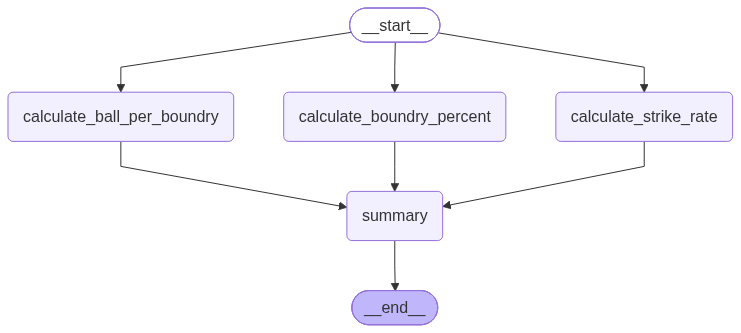

In [24]:
# print/visualize the graph
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [25]:
# execute the graph
initial_state = {"runs": 75, "balls": 48, "no_of_4s": 6, "no_of_6s": 3}
final_state = workflow.invoke(initial_state)
print(final_state["summary"])


    Strike Rate       : 156.25
    Balls per Boundry : 5.33
    Boundry Percentage: 56.00%
    
